# Benchmark: Gators vs Feature-Engine Encoders

This notebook compares the performance of **Gators encoders** (Polars-based) vs **feature-engine encoders** (pandas-based) across different dataset sizes.

**Objective**: Demonstrate Gators' multi-core processing advantages for categorical encoding tasks.

**Transformers Compared**:
- `gators.encoders.OneHotEncoder` vs `feature_engine.encoding.OneHotEncoder`
- `gators.encoders.OrdinalEncoder` vs `feature_engine.encoding.OrdinalEncoder`
- `gators.encoders.CountEncoder` vs `feature_engine.encoding.CountFrequencyEncoder`
- `gators.encoders.RareCategoryEncoder` vs `feature_engine.encoding.RareLabelEncoder`
- `gators.encoders.TargetEncoder` vs `feature_engine.encoding.MeanEncoder`
- `gators.encoders.WOEEncoder` vs `feature_engine.encoding.WoEEncoder`

**Dataset Sizes**: 1K, 10K, 100K, 1M rows

**Note**: Feature-engine operates on pandas DataFrames, while Gators uses Polars for multi-core parallel processing.

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

# Gators encoders
from gators.encoders import (
    OneHotEncoder,
    OrdinalEncoder,
    CountEncoder,
    RareCategoryEncoder,
    TargetEncoder,
    WOEEncoder
)

# Feature-engine encoders
from feature_engine.encoding import (
    OneHotEncoder as FEOneHotEncoder,
    OrdinalEncoder as FEOrdinalEncoder,
    CountFrequencyEncoder,
    RareLabelEncoder,
    MeanEncoder,
    WoEEncoder
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✅ Imports complete")
print(f"Feature-engine version: {__import__('feature_engine').__version__}")

✅ Imports complete
Feature-engine version: 1.9.4


## Utility Functions

In [2]:
# Import benchmark utilities
from benchmark import (
    generate_categorical_data,
    generate_binary_target,
    benchmark_transformer,
    DATASET_SIZES,
    DEFAULT_TIMEOUT
)

print("✅ Benchmark utilities imported from benchmark.py")

✅ Benchmark utilities imported from benchmark.py


## Generate Test Datasets

In [3]:
# Use dataset sizes from constants
dataset_sizes = DATASET_SIZES

# Generate datasets (deterministic - no randomness)
datasets = {}
for size in dataset_sizes:
    print(f"Generating {size:,} row dataset...")
    df_polars, df_pandas = generate_categorical_data(
        n_rows=size,
        n_low_cardinality=3,
        n_medium_cardinality=3,
        n_high_cardinality=2
    )
    
    # Generate binary target for supervised encoders (deterministic)
    y_polars, y_pandas = generate_binary_target(n_rows=size, positive_rate=0.3)
    
    datasets[size] = {
        'polars': df_polars,
        'pandas': df_pandas,
        'y_polars': y_polars,
        'y_pandas': y_pandas
    }
    print(f"  Polars: {df_polars.shape}, Pandas: {df_pandas.shape}")
    print(f"  Columns: {list(df_polars.columns)}")
    print(f"  Target: {y_polars.sum()} positives out of {size}")

print("\n✅ All datasets generated (deterministic - fully reproducible)")

Generating 1,000 row dataset...
  Polars: (1000, 8), Pandas: (1000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
  Target: 334 positives out of 1000
Generating 10,000 row dataset...
  Polars: (10000, 8), Pandas: (10000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
  Target: 3334 positives out of 10000
Generating 100,000 row dataset...
  Polars: (100000, 8), Pandas: (100000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
  Target: 33334 positives out of 100000
Generating 1,000,000 row dataset...
  Polars: (1000000, 8), Pandas: (1000000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
  Target: 333334 positives out of 1000000

✅ All datasets generated (determinis

In [ ]:
# Test with different cardinality levels
cardinality_groups = {
    'low': [col for col in datasets[1_000]['polars'].columns if col.startswith('low_')],
    'medium': [col for col in datasets[1_000]['polars'].columns if col.startswith('med_')],
    'high': [col for col in datasets[1_000]['polars'].columns if col.startswith('high_')]
}

## Benchmark 1: OneHot Encoding

Compare `gators.encoders.OneHotEncoder` vs `feature_engine.encoding.OneHotEncoder`.

In [5]:
onehot_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing OneHot Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders
        gators_enc = OneHotEncoder(subset=subset_cols, drop_columns=True)
        fe_enc = FEOneHotEncoder(variables=subset_cols, drop_last=False)
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        onehot_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
onehot_results_df = pd.DataFrame(onehot_results)
print("\n✅ OneHot encoding benchmarks complete")


Testing OneHot Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0009s, Feature-engine=0.0050s, Speedup=5.85x
    10,000 rows: Gators=0.0010s, Feature-engine=0.0146s, Speedup=14.46x
   100,000 rows: Gators=0.0022s, Feature-engine=0.1090s, Speedup=50.30x
  1,000,000 rows: Gators=0.0141s, Feature-engine=1.0397s, Speedup=73.86x

Testing OneHot Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0019s, Feature-engine=0.0215s, Speedup=11.17x
    10,000 rows: Gators=0.0019s, Feature-engine=0.0796s, Speedup=41.41x
   100,000 rows: Gators=0.0039s, Feature-engine=0.9694s, Speedup=247.66x
  1,000,000 rows: Gators=0.0301s, Feature-engine=12.4028s, Speedup=412.72x

Testing OneHot Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0040s, Feature-engine=0.0272s, Speedup=6.88x
    10,000 rows: Gators=0.0024s, Feature-engine=0.0908s, Speedup=37.12x
   100,000 rows: Gators=0.0048s, Feature-engine=1.2583s, Speedup=261.07x
  1,000,000 rows: Gators=0.1129s, Feat

## Benchmark 2: Ordinal Encoding

Compare `gators.encoders.OrdinalEncoder` vs `feature_engine.encoding.OrdinalEncoder`.

In [6]:
ordinal_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing Ordinal Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders
        gators_enc = OrdinalEncoder(subset=subset_cols, inplace=True)
        fe_enc = FEOrdinalEncoder(variables=subset_cols, encoding_method='arbitrary')
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        ordinal_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
ordinal_results_df = pd.DataFrame(ordinal_results)
print("\n✅ Ordinal encoding benchmarks complete")


Testing Ordinal Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0009s, Feature-engine=0.0014s, Speedup=1.59x
    10,000 rows: Gators=0.0024s, Feature-engine=0.0041s, Speedup=1.72x
   100,000 rows: Gators=0.0042s, Feature-engine=0.0229s, Speedup=5.45x
  1,000,000 rows: Gators=0.0321s, Feature-engine=0.2178s, Speedup=6.79x

Testing Ordinal Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0009s, Feature-engine=0.0014s, Speedup=1.52x
    10,000 rows: Gators=0.0011s, Feature-engine=0.0035s, Speedup=3.10x
   100,000 rows: Gators=0.0040s, Feature-engine=0.0233s, Speedup=5.90x
  1,000,000 rows: Gators=0.0311s, Feature-engine=0.2216s, Speedup=7.13x

Testing Ordinal Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0007s, Feature-engine=0.0011s, Speedup=1.64x
    10,000 rows: Gators=0.0009s, Feature-engine=0.0026s, Speedup=3.00x
   100,000 rows: Gators=0.0029s, Feature-engine=0.0166s, Speedup=5.70x
  1,000,000 rows: Gators=0.0221s, Feature-engine

## Benchmark 3: Count/Frequency Encoding

Compare `gators.encoders.CountEncoder` vs `feature_engine.encoding.CountFrequencyEncoder`.

In [7]:
count_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing Count Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders
        gators_enc = CountEncoder(subset=subset_cols, inplace=True)
        fe_enc = CountFrequencyEncoder(variables=subset_cols, encoding_method='count')
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        count_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
count_results_df = pd.DataFrame(count_results)
print("\n✅ Count encoding benchmarks complete")


Testing Count Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0005s, Feature-engine=0.0020s, Speedup=4.08x
    10,000 rows: Gators=0.0008s, Feature-engine=0.0035s, Speedup=4.21x
   100,000 rows: Gators=0.0035s, Feature-engine=0.0217s, Speedup=6.15x
  1,000,000 rows: Gators=0.0315s, Feature-engine=0.2050s, Speedup=6.51x

Testing Count Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0005s, Feature-engine=0.0015s, Speedup=3.21x
    10,000 rows: Gators=0.0009s, Feature-engine=0.0034s, Speedup=3.65x
   100,000 rows: Gators=0.0036s, Feature-engine=0.0220s, Speedup=6.11x
  1,000,000 rows: Gators=0.0291s, Feature-engine=0.2088s, Speedup=7.18x

Testing Count Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0005s, Feature-engine=0.0013s, Speedup=2.29x
    10,000 rows: Gators=0.0006s, Feature-engine=0.0026s, Speedup=4.11x
   100,000 rows: Gators=0.0025s, Feature-engine=0.0152s, Speedup=6.16x
  1,000,000 rows: Gators=0.0222s, Feature-engine=0.140

## Benchmark 4: Rare Category Encoding

Compare `gators.encoders.RareCategoryEncoder` vs `feature_engine.encoding.RareLabelEncoder`.

In [8]:
rare_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing Rare Category Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders (use min_count threshold)
        gators_enc = RareCategoryEncoder(subset=subset_cols, min_count=10, inplace=True)
        fe_enc = RareLabelEncoder(variables=subset_cols, tol=0.01, replace_with='Rare')
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        rare_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
rare_results_df = pd.DataFrame(rare_results)
print("\n✅ Rare category encoding benchmarks complete")


Testing Rare Category Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0003s, Feature-engine=0.0011s, Speedup=3.63x
    10,000 rows: Gators=0.0005s, Feature-engine=0.0037s, Speedup=8.03x
   100,000 rows: Gators=0.0025s, Feature-engine=0.0264s, Speedup=10.49x
  1,000,000 rows: Gators=0.0251s, Feature-engine=0.2584s, Speedup=10.31x

Testing Rare Category Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0002s, Feature-engine=0.0014s, Speedup=6.07x
    10,000 rows: Gators=0.0005s, Feature-engine=0.0038s, Speedup=7.70x
   100,000 rows: Gators=0.0022s, Feature-engine=0.0269s, Speedup=12.29x
  1,000,000 rows: Gators=0.0236s, Feature-engine=0.2546s, Speedup=10.79x

Testing Rare Category Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0001s, Feature-engine=0.0012s, Speedup=8.31x
    10,000 rows: Gators=0.0003s, Feature-engine=0.0027s, Speedup=10.48x
   100,000 rows: Gators=0.0015s, Feature-engine=0.0183s, Speedup=12.38x
  1,000,000 rows: Gators

## Benchmark 5: Target Encoding

Compare `gators.encoders.TargetEncoder` vs `feature_engine.encoding.MeanEncoder`.

**Note**: These are supervised encoders that use the target variable.

In [11]:
target_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing Target Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        y_polars = datasets[size]['y_polars']
        y_pandas = datasets[size]['y_pandas']
        
        # Create encoders
        gators_enc = TargetEncoder(subset=subset_cols, inplace=True)
        fe_enc = MeanEncoder(variables=subset_cols)
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            y_polars=y_polars,
            y_pandas=y_pandas,
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        target_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
target_results_df = pd.DataFrame(target_results)
print("\n✅ Target encoding benchmarks complete")


Testing Target Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0018s, Feature-engine=0.0035s, Speedup=1.92x
    10,000 rows: Gators=0.0018s, Feature-engine=0.0055s, Speedup=3.01x
   100,000 rows: Gators=0.0039s, Feature-engine=0.0312s, Speedup=8.05x
  1,000,000 rows: Gators=0.0323s, Feature-engine=0.2935s, Speedup=9.08x

Testing Target Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0019s, Feature-engine=0.0028s, Speedup=1.43x
    10,000 rows: Gators=0.0022s, Feature-engine=0.0059s, Speedup=2.73x
   100,000 rows: Gators=0.0047s, Feature-engine=0.0341s, Speedup=7.26x
  1,000,000 rows: Gators=0.0393s, Feature-engine=0.2956s, Speedup=7.53x

Testing Target Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0020s, Feature-engine=0.0024s, Speedup=1.16x
    10,000 rows: Gators=0.0022s, Feature-engine=0.0043s, Speedup=1.96x
   100,000 rows: Gators=0.0038s, Feature-engine=0.0216s, Speedup=5.68x
  1,000,000 rows: Gators=0.0231s, Feature-engine=0.

## Benchmark 6: Weight of Evidence (WOE) Encoding

Compare `gators.encoders.WOEEncoder` vs `feature_engine.encoding.WoEEncoder`.

**Note**: These are supervised encoders that use the target variable.

In [12]:
woe_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing WOE Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        y_polars = datasets[size]['y_polars']
        y_pandas = datasets[size]['y_pandas']
        
        # Create encoders
        gators_enc = WOEEncoder(subset=subset_cols, inplace=True)
        fe_enc = WoEEncoder(variables=subset_cols)
        
        # Benchmark with timeout
        results = benchmark_transformer(
            gators_enc,
            fe_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            y_polars=y_polars,
            y_pandas=y_pandas,
            n_runs=3,
            timeout_seconds=DEFAULT_TIMEOUT
        )
        
        # Store results
        woe_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'fe_fit': results['comparison_fit'],
            'fe_transform': results['comparison_transform'],
            'fe_total': results['comparison_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Feature-engine={results['comparison_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
woe_results_df = pd.DataFrame(woe_results)
print("\n✅ WOE encoding benchmarks complete")


Testing WOE Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0026s, Feature-engine=0.0027s, Speedup=1.02x
    10,000 rows: Gators=0.0039s, Feature-engine=0.0056s, Speedup=1.45x
   100,000 rows: Gators=0.0053s, Feature-engine=0.0372s, Speedup=6.98x
  1,000,000 rows: Gators=0.0323s, Feature-engine=0.3162s, Speedup=9.78x

Testing WOE Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0034s, Feature-engine=0.0026s, Speedup=0.76x
    10,000 rows: Gators=0.0034s, Feature-engine=0.0058s, Speedup=1.72x
   100,000 rows: Gators=0.0059s, Feature-engine=0.0344s, Speedup=5.78x
  1,000,000 rows: Gators=0.0362s, Feature-engine=0.3251s, Speedup=8.97x

Testing WOE Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0030s, Feature-engine=0.0022s, Speedup=0.72x
    10,000 rows: Gators=0.0033s, Feature-engine=0.0042s, Speedup=1.29x
   100,000 rows: Gators=0.0049s, Feature-engine=0.0235s, Speedup=4.78x
  1,000,000 rows: Gators=0.0251s, Feature-engine=0.2193s, Sp

## Results Visualization

In [35]:
from benchmark import plot_speedup_scaling
plot_speedup_scaling(all_results, dataset_sizes)

ImportError: cannot import name 'plot_speedup_scaling' from 'benchmark' (/Users/cpoli/Desktop/DUMMY/docs/source/examples/benchmark.py)

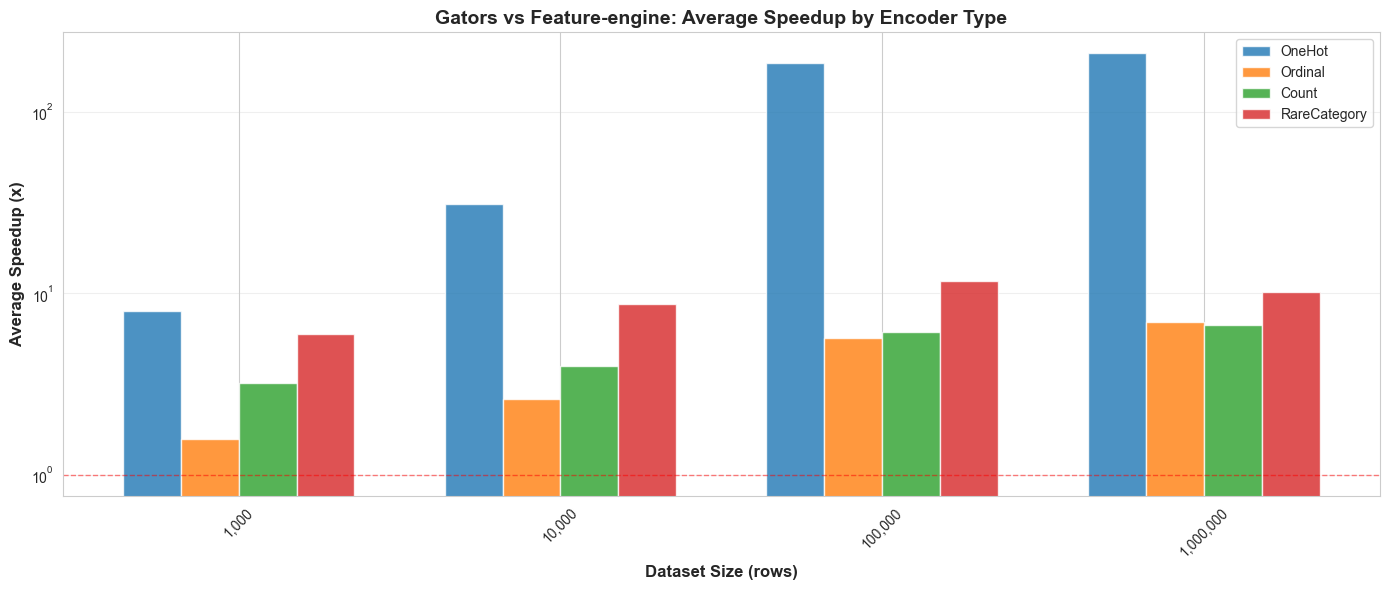

In [ ]:
# Plot 1: Speedup comparison across all encoder types
fig, ax = plt.subplots(figsize=(14, 6))

encoder_types = ['OneHot', 'Ordinal', 'Count', 'RareCategory']
x_pos = np.arange(len(dataset_sizes))
width = 0.18

for idx, encoder_type in enumerate(encoder_types):
    data = all_results[all_results['encoder_type'] == encoder_type]
    speedups = [data[data['dataset_size'] == size]['speedup_total'].mean() for size in dataset_sizes]
    
    ax.bar(x_pos + idx * width, speedups, width, label=encoder_type, alpha=0.8)

ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Speedup (x)', fontsize=12, fontweight='bold')
ax.set_title('Gators vs Feature-engine: Average Speedup by Encoder Type', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels([f'{size:,}' for size in dataset_sizes], rotation=45)
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='No speedup', alpha=0.5)

plt.tight_layout()
plt.show()

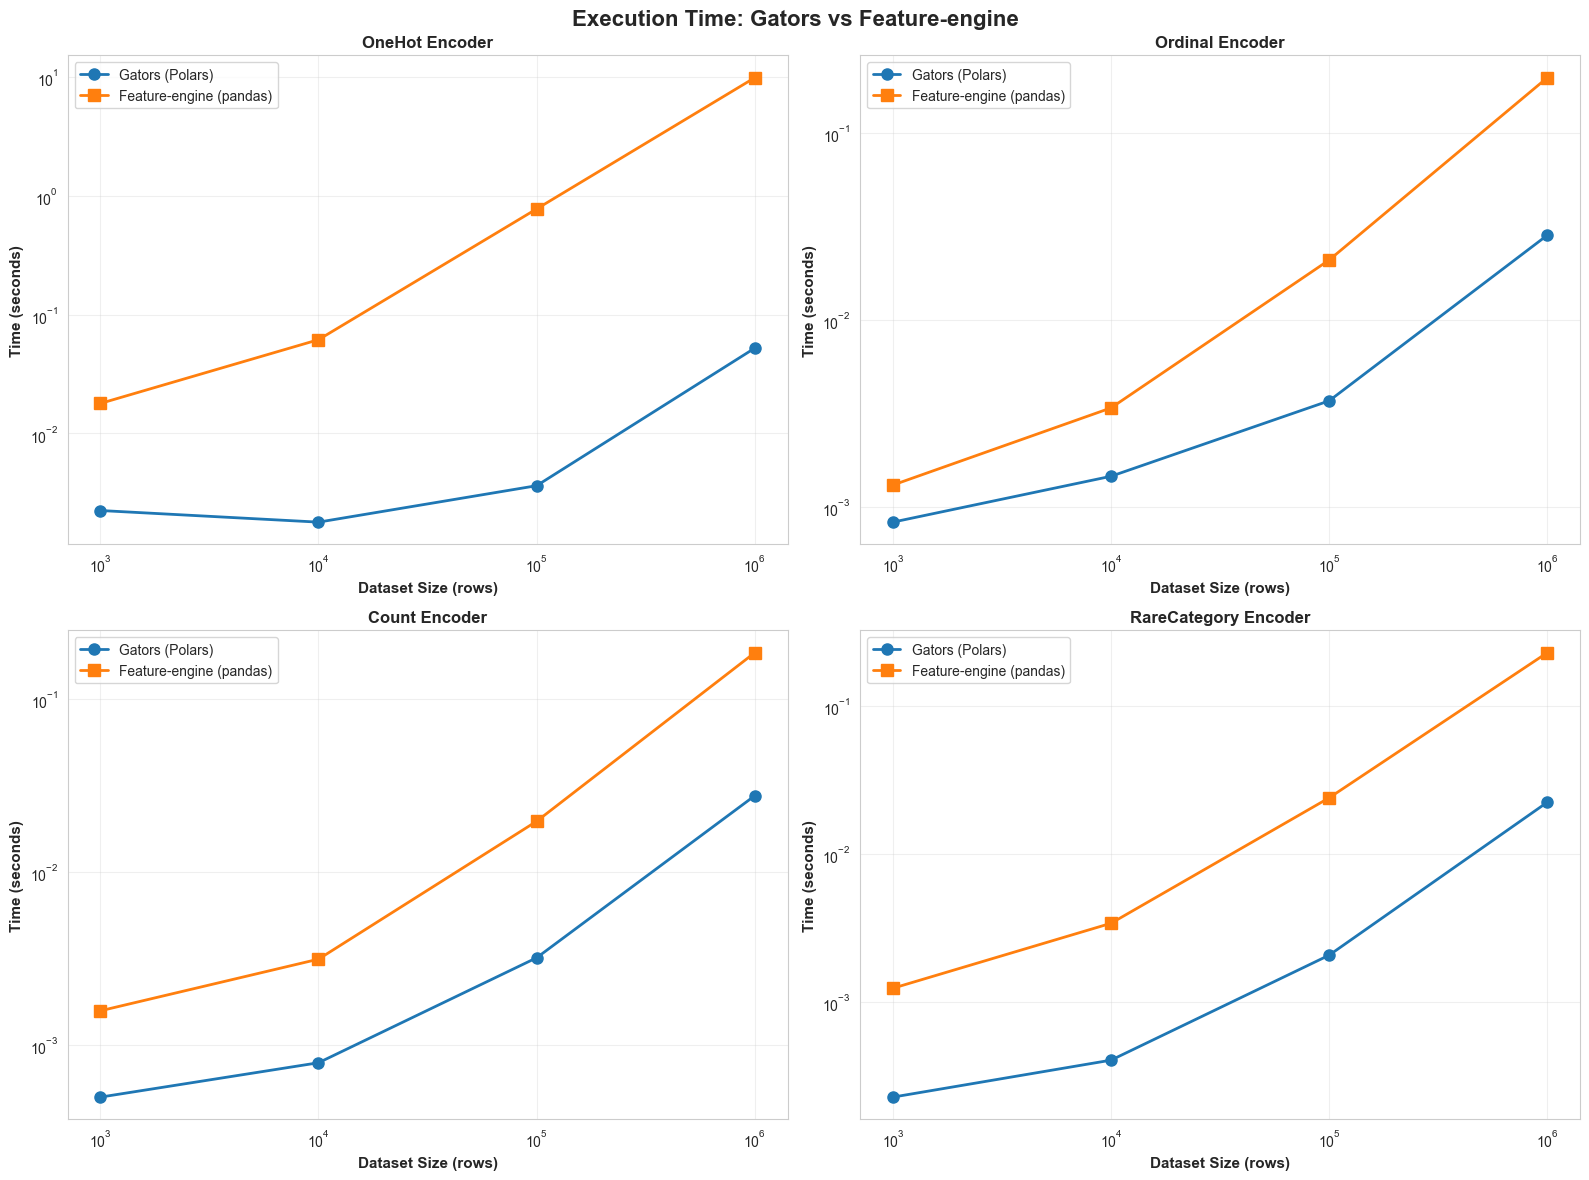

In [16]:
# Plot 2: Execution time comparison for each encoder type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Execution Time: Gators vs Feature-engine', fontsize=16, fontweight='bold')

for idx, encoder_type in enumerate(encoder_types):
    ax = axes[idx // 2, idx % 2]
    
    data = all_results[all_results['encoder_type'] == encoder_type]
    
    # Aggregate by dataset size (average across cardinalities)
    gators_times = [data[data['dataset_size'] == size]['gators_total'].mean() for size in dataset_sizes]
    fe_times = [data[data['dataset_size'] == size]['fe_total'].mean() for size in dataset_sizes]
    
    ax.plot(dataset_sizes, gators_times, marker='o', label='Gators (Polars)', linewidth=2, markersize=8)
    ax.plot(dataset_sizes, fe_times, marker='s', label='Feature-engine (pandas)', linewidth=2, markersize=8)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Dataset Size (rows)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f'{encoder_type} Encoder', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

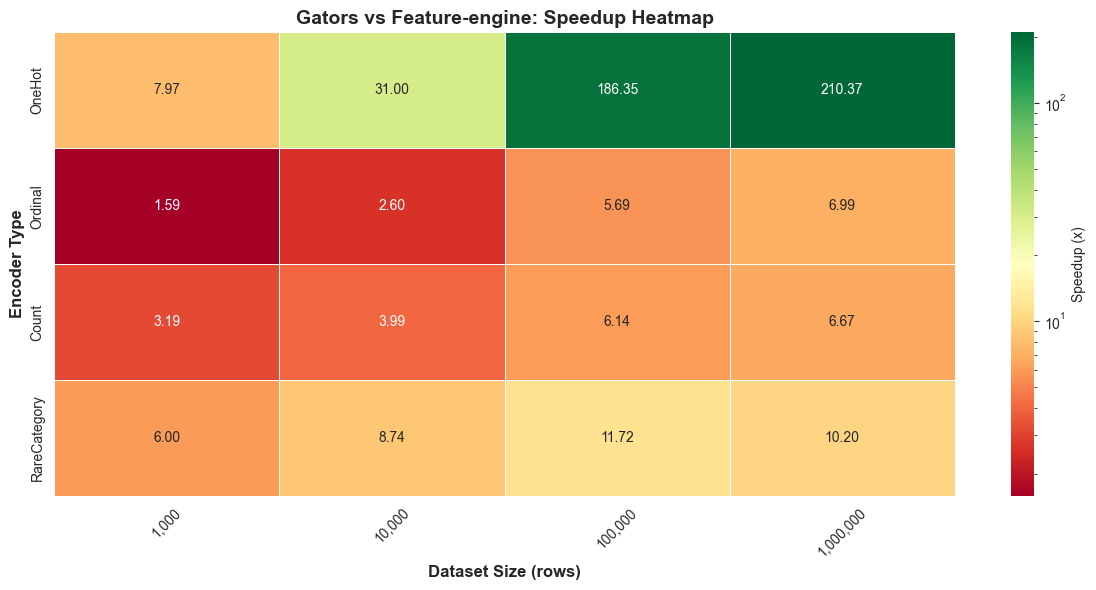

In [34]:
# Plot 3: Heatmap of speedup by encoder type and dataset size
pivot = all_results.groupby(['encoder_type', 'dataset_size'])['speedup_total'].mean().reset_index()
pivot_table = pivot.pivot(index='encoder_type', columns='dataset_size', values='speedup_total')
pivot_table = pivot_table.reindex(['OneHot', 'Ordinal', 'Count', 'RareCategory'])

fig, ax = plt.subplots(figsize=(12, 6))

# Use logarithmic normalization for skewed speedup values
from matplotlib.colors import LogNorm
sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', 
            norm=LogNorm(vmin=pivot_table.min().min(), vmax=pivot_table.max().max()),
            cbar_kws={'label': 'Speedup (x)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
ax.set_ylabel('Encoder Type', fontsize=12, fontweight='bold')
ax.set_title('Gators vs Feature-engine: Speedup Heatmap', fontsize=14, fontweight='bold')
ax.set_xticklabels([f'{int(col):,}' for col in pivot_table.columns], rotation=45)

plt.tight_layout()
plt.show()

## Summary Statistics

In [23]:
# Summary by encoder type
summary_by_encoder = all_results.groupby('encoder_type').agg({
    'gators_total': 'mean',
    'fe_total': 'mean',
    'speedup_total': 'mean'
}).round(4)

summary_by_encoder.columns = ['Avg Gators Time (s)', 'Avg Feature-engine Time (s)', 'Avg Speedup']
summary_by_encoder = summary_by_encoder.sort_values('Avg Speedup', ascending=False)

print("\n" + "="*80)
print("SUMMARY BY ENCODER TYPE")
print("="*80)
print(summary_by_encoder.to_string())

# Summary by dataset size
summary_by_size = all_results.groupby('dataset_size').agg({
    'gators_total': 'mean',
    'fe_total': 'mean',
    'speedup_total': 'mean'
}).round(4)

summary_by_size.columns = ['Avg Gators Time (s)', 'Avg Feature-engine Time (s)', 'Avg Speedup']
summary_by_size.index = [f'{size:,} rows' for size in summary_by_size.index]

print("\n" + "="*80)
print("SUMMARY BY DATASET SIZE")
print("="*80)
print(summary_by_size.to_string())
print("\n" + "="*80)


SUMMARY BY ENCODER TYPE
              Avg Gators Time (s)  Avg Feature-engine Time (s)  Avg Speedup
encoder_type                                                               
OneHot                     0.0150                       2.6951     108.9197
RareCategory               0.0062                       0.0643       9.1645
Count                      0.0080                       0.0523       4.9990
Ordinal                    0.0086                       0.0560       4.2170

SUMMARY BY DATASET SIZE
                Avg Gators Time (s)  Avg Feature-engine Time (s)  Avg Speedup
1,000 rows                   0.0009                       0.0055       4.6874
10,000 rows                  0.0011                       0.0179      11.5817
100,000 rows                 0.0031                       0.2108      52.4728
1,000,000 rows               0.0327                       2.6335      58.5583

